betül danışmaz


In [ ]:
# Step 1.1: Kaggle Login
import kagglehub
kagglehub.login()

Kaggle credentials set.
Kaggle credentials successfully validated.


In [ ]:
# Step 1.2: Download Competition Data
yzta_2026_datathon_path = kagglehub.competition_download('yzta-2026-datathon')
print('Data source import complete.')

Data source import complete.


In [ ]:
# Step 1.3: File Organization
import os
import shutil
dest_dir = '/content/yzta-2026-datathon'
os.makedirs(dest_dir, exist_ok=True)
for file in os.listdir(yzta_2026_datathon_path):
    shutil.copy(os.path.join(yzta_2026_datathon_path, file), dest_dir)
yzta_2026_datathon_path = dest_dir

In [ ]:
import os

data_path = "/content/yzta-2026-datathon"

print(os.listdir(data_path))


['train.csv', 'test_x.csv', 'sample_submission.csv']


In [ ]:
# Step 1.4: Load DataFrames
import pandas as pd
import numpy as np
train = pd.read_csv(os.path.join(data_path, 'train.csv'))
test = pd.read_csv(os.path.join(data_path, 'test_x.csv'))
sample_submission = pd.read_csv(os.path.join(data_path, 'sample_submission.csv'))

In [ ]:
print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Sample submission shape:", sample_submission.shape)

display(train.head())
display(test.head())
display(sample_submission.head())

Train shape: (56000, 24)
Test shape: (24000, 23)
Sample submission shape: (2, 2)


,id,yas,cinsiyet,meslek,vucut_kitle_indeksi,ulke,rem_yuzdesi,derin_uyku_yuzdesi,uykuya_dalma_suresi_dk,gecelik_uyanma_sayisi,...,stres_skoru,gunluk_calisma_saati,kronotip,ruh_sagligi_durumu,dinlenik_nabiz_bpm,oda_sicakligi_celsius,hafta_sonu_uyku_farki_saat,mevsim,gun_tipi,bilissel_performans_skoru
0,1,34,Erkek,Saglik Personeli,31.470103,Cin,14.431210,14.645436,27,7,...,9.922976,10.045274,Sabah insani,Anksiyete ve depresyon,78,18.962436,-0.074140,Sonbahar-Kis,Hafta ici,0.136441
1,2,32,Kadin,Muhendis,30.981394,Amerika,21.771870,27.220360,20,4,...,6.626400,6.319245,Gece insani,Saglikli,76,21.225666,0.942672,Sonbahar-Kis,Hafta ici,5.848312
2,3,39,Erkek,Ev Hanimi,21.533898,Spain,18.178857,25.530104,33,7,...,6.093566,3.824463,Notr,Depresyon,66,18.482409,1.239886,Ilkbahar-Yaz,Hafta sonu,6.828276
3,4,40,Kadin,Egitimci,23.310749,Yeni Zelanda,21.438151,15.891188,21,2,...,3.168185,4.597316,Gece insani,Saglikli,60,21.862235,0.727695,Sonbahar-Kis,Hafta sonu,8.144649
4,5,36,Kadin,NaN,NaN,Portekiz,25.468018,16.356738,21,8,...,7.198574,3.189120,Notr,Anksiyete ve depresyon,74,19.223195,-0.223402,Sonbahar-Kis,Hafta ici,0.431423


,id,yas,cinsiyet,meslek,vucut_kitle_indeksi,ulke,rem_yuzdesi,derin_uyku_yuzdesi,uykuya_dalma_suresi_dk,gecelik_uyanma_sayisi,...,sekerleme_suresi_dk,stres_skoru,gunluk_calisma_saati,kronotip,ruh_sagligi_durumu,dinlenik_nabiz_bpm,oda_sicakligi_celsius,hafta_sonu_uyku_farki_saat,mevsim,gun_tipi
0,1,42,Erkek,Saglik Personeli,29.728724,Ingiltere,21.691917,23.990157,21,5,...,0,6.349196,9.419561,Gece insani,Depresyon,82,21.627129,1.716161,Ilkbahar-Yaz,Hafta sonu
1,2,26,Kadin,Serbest Calisan,32.865996,Cin,22.090624,18.231963,34,5,...,0,NaN,8.574199,Gece insani,Saglikli,66,27.835934,1.482283,Ilkbahar-Yaz,Hafta ici
2,3,21,Erkek,Lojistik Calisani,24.438264,Cin,19.488438,16.695363,17,4,...,52,6.715192,10.519017,Notr,Depresyon,63,20.252258,1.981034,Sonbahar-Kis,Hafta ici
3,4,61,Kadin,Saglik Personeli,23.275057,Cin,26.831092,21.762040,29,2,...,2,5.633400,9.814789,Gece insani,Saglikli,71,17.680971,0.589750,Sonbahar-Kis,Hafta ici
4,5,26,Kadin,Saglik Personeli,24.815531,Ingiltere,16.271522,18.153212,15,4,...,0,7.953794,9.308398,Sabah insani,Saglikli,53,23.698979,0.622211,Ilkbahar-Yaz,Hafta ici


,id,bilissel_performans_skoru
0,1,7.85
1,2,4.32


In [ ]:
print("Train columns:")
print(train.columns.tolist())

print("\nTest columns:")
print(test.columns.tolist())

print("\nSubmission columns:")
print(sample_submission.columns.tolist())

Train columns:
['id', 'yas', 'cinsiyet', 'meslek', 'vucut_kitle_indeksi', 'ulke', 'rem_yuzdesi', 'derin_uyku_yuzdesi', 'uykuya_dalma_suresi_dk', 'gecelik_uyanma_sayisi', 'uyku_oncesi_kafein_mg', 'uyku_oncesi_ekran_suresi_dk', 'gunluk_adim_sayisi', 'sekerleme_suresi_dk', 'stres_skoru', 'gunluk_calisma_saati', 'kronotip', 'ruh_sagligi_durumu', 'dinlenik_nabiz_bpm', 'oda_sicakligi_celsius', 'hafta_sonu_uyku_farki_saat', 'mevsim', 'gun_tipi', 'bilissel_performans_skoru']

Test columns:
['id', 'yas', 'cinsiyet', 'meslek', 'vucut_kitle_indeksi', 'ulke', 'rem_yuzdesi', 'derin_uyku_yuzdesi', 'uykuya_dalma_suresi_dk', 'gecelik_uyanma_sayisi', 'uyku_oncesi_kafein_mg', 'uyku_oncesi_ekran_suresi_dk', 'gunluk_adim_sayisi', 'sekerleme_suresi_dk', 'stres_skoru', 'gunluk_calisma_saati', 'kronotip', 'ruh_sagligi_durumu', 'dinlenik_nabiz_bpm', 'oda_sicakligi_celsius', 'hafta_sonu_uyku_farki_saat', 'mevsim', 'gun_tipi']

Submission columns:
['id', 'bilissel_performans_skoru']


In [ ]:
target = "bilissel_performans_skoru"
id_col = "id"

print("Target in train:", target in train.columns)
print("Target in test:", target in test.columns)
print("ID in train:", id_col in train.columns)
print("ID in test:", id_col in test.columns)
print("ID in sample_submission:", id_col in sample_submission.columns)
print("Target in sample_submission:", target in sample_submission.columns)

Target in train: True
Target in test: False
ID in train: True
ID in test: True
ID in sample_submission: True
Target in sample_submission: True


In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56000 entries, 0 to 55999
Data columns (total 24 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id                           56000 non-null  int64  
 1   yas                          56000 non-null  int64  
 2   cinsiyet                     56000 non-null  object 
 3   meslek                       54622 non-null  object 
 4   vucut_kitle_indeksi          54248 non-null  float64
 5   ulke                         56000 non-null  object 
 6   rem_yuzdesi                  56000 non-null  float64
 7   derin_uyku_yuzdesi           56000 non-null  float64
 8   uykuya_dalma_suresi_dk       56000 non-null  int64  
 9   gecelik_uyanma_sayisi        56000 non-null  int64  
 10  uyku_oncesi_kafein_mg        54537 non-null  float64
 11  uyku_oncesi_ekran_suresi_dk  56000 non-null  int64  
 12  gunluk_adim_sayisi           56000 non-null  int64  
 13  sekerleme_suresi

In [ ]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24000 entries, 0 to 23999
Data columns (total 23 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id                           24000 non-null  int64  
 1   yas                          24000 non-null  int64  
 2   cinsiyet                     24000 non-null  object 
 3   meslek                       23378 non-null  object 
 4   vucut_kitle_indeksi          23352 non-null  float64
 5   ulke                         24000 non-null  object 
 6   rem_yuzdesi                  24000 non-null  float64
 7   derin_uyku_yuzdesi           24000 non-null  float64
 8   uykuya_dalma_suresi_dk       24000 non-null  int64  
 9   gecelik_uyanma_sayisi        24000 non-null  int64  
 10  uyku_oncesi_kafein_mg        23303 non-null  float64
 11  uyku_oncesi_ekran_suresi_dk  24000 non-null  int64  
 12  gunluk_adim_sayisi           24000 non-null  int64  
 13  sekerleme_suresi

In [ ]:
train[target].describe()

,bilissel_performans_skoru
count,56000.000000
mean,5.913096
std,2.231759
min,0.000000
25%,4.397431
50%,6.032249
75%,7.574980
max,10.000000


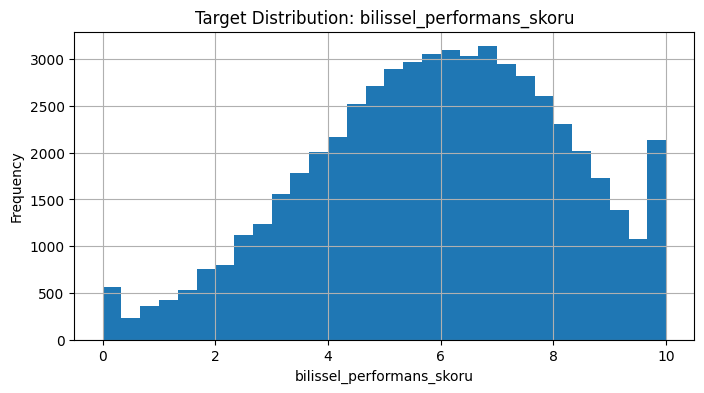

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
train[target].hist(bins=30)
plt.title("Target Distribution: bilissel_performans_skoru")
plt.xlabel("bilissel_performans_skoru")
plt.ylabel("Frequency")
plt.show()

In [ ]:
# Step 2.1: Initial X/Y Separation
target = 'bilissel_performans_skoru'
id_col = 'id'
feature_cols = [col for col in train.columns if col not in [target, id_col]]
X = train[feature_cols]
y = train[target]

In [ ]:
# Step 2.2: Feature Type Identification
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()

In [ ]:
# Check whether train and test have the same feature columns
missing_in_test = set(feature_cols) - set(test.columns)
extra_in_test = set(test.columns) - set(feature_cols) - {id_col}

print("Missing feature columns in test:", missing_in_test)
print("Extra columns in test:", extra_in_test)

Missing feature columns in test: set()
Extra columns in test: set()


In [ ]:
print("Missing values in train:")
display(train[feature_cols].isnull().sum().sort_values(ascending=False))

print("\nMissing values in test:")
display(test[feature_cols].isnull().sum().sort_values(ascending=False))

Missing values in train:


,0
kronotip,1968
vucut_kitle_indeksi,1752
stres_skoru,1715
uyku_oncesi_kafein_mg,1463
meslek,1378
ruh_sagligi_durumu,1096
rem_yuzdesi,0
ulke,0
yas,0
cinsiyet,0



Missing values in test:


,0
kronotip,832
stres_skoru,765
uyku_oncesi_kafein_mg,697
vucut_kitle_indeksi,648
meslek,622
ruh_sagligi_durumu,504
rem_yuzdesi,0
ulke,0
yas,0
cinsiyet,0


In [ ]:
print("Categorical Cardinality (Unique Values):")
cardinality = train[categorical_features].nunique().sort_values(ascending=False)
display(cardinality)

print("\nTop 5 category frequencies for high-cardinality features:")
for col in cardinality.index[:3]: # Check the top 3 most diverse columns
    print(f"\n--- {col} ---")
    display(train[col].value_counts(normalize=True).head(5))

# Best course of action:
# 1. Use One-Hot Encoding for all categories as the total number of features remains manageable.
# 2. Set handle_unknown='ignore' to robustly manage unseen categories in the test set.
# 3. If cardinality for 'ulke' or 'meslek' is extremely high (>50), consider Target Encoding in later iterations.

Categorical Cardinality (Unique Values):


,0
ulke,15
meslek,11
ruh_sagligi_durumu,4
kronotip,3
cinsiyet,2
mevsim,2
gun_tipi,2



Top 5 category frequencies for high-cardinality features:

--- ulke ---


,proportion
ulke,
Ingiltere,0.202214
Cin,0.178375
Guney Kore,0.079625
Amerika,0.079411
Arjantin,0.070946



--- meslek ---


,proportion
meslek,
Saglik Personeli,0.180184
Ogrenci,0.148878
Muhendis,0.119604
Yonetici,0.081542
Egitimci,0.080462



--- ruh_sagligi_durumu ---


,proportion
ruh_sagligi_durumu,
Saglikli,0.698765
Anksiyete,0.150627
Depresyon,0.100248
Anksiyete ve depresyon,0.050361


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# Ensure feature lists are clean
target = "bilissel_performans_skoru"
id_col = "id"
feature_cols = [col for col in train.columns if col not in [target, id_col]]

numeric_features = train[feature_cols].select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = train[feature_cols].select_dtypes(include=['object', 'category']).columns.tolist()

# Define X and y
X = train[feature_cols]
y = train[target]

# Prepare final test set features
X_test_final = test[feature_cols]

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Final test features shape: {X_test_final.shape}")

X shape: (56000, 22)
y shape: (56000,)
Final test features shape: (24000, 22)


In [ ]:
from sklearn.model_selection import train_test_split

# Perform the split
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(f"X_train shape: {X_train.shape}")
print(f"X_valid shape: {X_valid.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_valid shape: {y_valid.shape}")

X_train shape: (44800, 22)
X_valid shape: (11200, 22)
y_train shape: (44800,)
y_valid shape: (11200,)


In [ ]:
try:
    onehot = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
except TypeError:
    # Support for older scikit-learn versions
    onehot = OneHotEncoder(handle_unknown='ignore', sparse=False)

# Numeric transformation pipeline: Impute with median, then scale
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical transformation pipeline: Impute with mode, then One-Hot Encode
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', onehot)
])

# Combine into a single preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline defined successfully.")

Preprocessing pipeline defined successfully.


CATBOOST VS LIGHTGBM

In [ ]:
# Step 3.1: Install Dependencies
!pip install lightgbm catboost -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.1 MB/s eta 0:00:00


In [ ]:
# Step 3.2: Evaluation Metrics Definition
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
def evaluate_predictions(y_true, preds, model_name='model'):
    preds = np.clip(preds, 0, 10)
    rmse = np.sqrt(mean_squared_error(y_true, preds))
    print(f'{model_name} RMSE: {rmse:.5f}')
    return rmse

In [ ]:
from catboost import CatBoostRegressor

X_cat = X.copy()

# CatBoost needs categorical missing values as strings
for col in categorical_features:
    X_cat[col] = X_cat[col].fillna("Missing")

X_train_cat, X_valid_cat, y_train_cat, y_valid_cat = train_test_split(
    X_cat,
    y,
    test_size=0.2,
    random_state=42
)

cat_feature_indices = [
    X_cat.columns.get_loc(col) for col in categorical_features
]

cat_model = CatBoostRegressor(
    iterations=800,
    learning_rate=0.03,
    depth=6,
    l2_leaf_reg=4,
    loss_function="RMSE",
    random_seed=42,
    verbose=100,
    allow_writing_files=False
)

cat_model.fit(
    X_train_cat,
    y_train_cat,
    cat_features=cat_feature_indices,
    eval_set=(X_valid_cat, y_valid_cat),
    use_best_model=True,
    early_stopping_rounds=80
)

cat_valid_preds = cat_model.predict(X_valid_cat)

cat_result = evaluate_predictions(
    y_valid_cat,
    cat_valid_preds,
    model_name="CatBoost"
)

0:	learn: 2.1942302	test: 2.2053970	best: 2.2053970 (0)	total: 47.4ms	remaining: 37.9s
100:	learn: 1.2953719	test: 1.3039923	best: 1.3039923 (100)	total: 3.59s	remaining: 24.9s
200:	learn: 1.2308931	test: 1.2462032	best: 1.2462032 (200)	total: 8.19s	remaining: 24.4s
300:	learn: 1.2127838	test: 1.2323615	best: 1.2323615 (300)	total: 12.1s	remaining: 20.1s
400:	learn: 1.2031123	test: 1.2267422	best: 1.2267422 (400)	total: 15.7s	remaining: 15.6s
500:	learn: 1.1956265	test: 1.2242253	best: 1.2241933 (492)	total: 19.6s	remaining: 11.7s
600:	learn: 1.1899629	test: 1.2227689	best: 1.2227689 (600)	total: 23.8s	remaining: 7.89s
700:	learn: 1.1851308	test: 1.2220836	best: 1.2220836 (700)	total: 27.2s	remaining: 3.85s
799:	learn: 1.1807297	test: 1.2216898	best: 1.2216757 (795)	total: 30.6s	remaining: 0us

bestTest = 1.221675711
bestIteration = 795

Shrink model to first 796 iterations.
CatBoost
MAE : 0.97888
RMSE: 1.22150
R2  : 0.70285


In [ ]:
# Step 4.1: Prepare Categorical Data (X_cat)
from sklearn.model_selection import KFold
X_cat = X.copy()
for col in categorical_features:
    X_cat[col] = X_cat[col].fillna('Missing').astype(str)
current_cat_idx = [X_cat.columns.get_loc(col) for col in categorical_features]

In [ ]:
# Step 4.2: Core CV Evaluation Function
from catboost import CatBoostRegressor
def evaluate_catboost_cv(params, X_data, y_data, cat_features, n_splits=5):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    fold_results = []
    for fold, (train_idx, valid_idx) in enumerate(kf.split(X_data), start=1):
        X_tr, X_val = X_data.iloc[train_idx], X_data.iloc[valid_idx]
        y_tr, y_val = y_data.iloc[train_idx], y_data.iloc[valid_idx]
        model = CatBoostRegressor(loss_function='RMSE', eval_metric='RMSE', random_seed=42, verbose=0, **params)
        model.fit(X_tr, y_tr, cat_features=cat_features, eval_set=(X_val, y_val), use_best_model=True, early_stopping_rounds=100)
        preds = np.clip(model.predict(X_val), 0, 10)
        fold_results.append({'fold': fold, 'RMSE': np.sqrt(mean_squared_error(y_val, preds)), 'best_iteration': model.get_best_iteration()})
    return pd.DataFrame(fold_results)

In [ ]:
# [OUTDATED/EXPERIMENTAL] - Replaced by Step 6.1 Tuning
# catboost_base_params = { ... }

Fold 1 RMSE: 1.22202
Fold 2 RMSE: 1.21703
Fold 3 RMSE: 1.20195
Fold 4 RMSE: 1.20957
Fold 5 RMSE: 1.23237

Mean CV RMSE: 1.2165870806086647
Std CV RMSE : 0.011642088947747934
Mean CV MAE : 0.9710413010259824
Mean CV R2  : 0.7028133238867268


,fold,RMSE,MAE,R2,best_iteration
0,1,1.222017,0.979325,0.702592,798
1,2,1.217028,0.970581,0.700599,797
2,3,1.201949,0.960899,0.709715,778
3,4,1.209574,0.963622,0.704070,771
4,5,1.232367,0.980780,0.697092,792


In [ ]:
catboost_candidates = {
    "cat_base_800": {
        "iterations": 800,
        "learning_rate": 0.03,
        "depth": 6,
        "l2_leaf_reg": 4
    },

    "cat_1200_lr0025_depth6": {
        "iterations": 1200,
        "learning_rate": 0.025,
        "depth": 6,
        "l2_leaf_reg": 4
    },

    "cat_1600_lr002_depth6_reg6": {
        "iterations": 1600,
        "learning_rate": 0.02,
        "depth": 6,
        "l2_leaf_reg": 6
    },

    "cat_2000_lr0015_depth6_reg8": {
        "iterations": 2000,
        "learning_rate": 0.015,
        "depth": 6,
        "l2_leaf_reg": 8
    },

    "cat_1200_lr0025_depth5_reg4": {
        "iterations": 1200,
        "learning_rate": 0.025,
        "depth": 5,
        "l2_leaf_reg": 4
    },

    "cat_1600_lr002_depth7_reg10": {
        "iterations": 1600,
        "learning_rate": 0.02,
        "depth": 7,
        "l2_leaf_reg": 10
    },

    "cat_1600_lr002_depth6_reg10_random": {
        "iterations": 1600,
        "learning_rate": 0.02,
        "depth": 6,
        "l2_leaf_reg": 10,
        "random_strength": 1.0,
        "bagging_temperature": 0.5
    }
}

In [ ]:
tuning_results = []

for name, params in catboost_candidates.items():
    print(f"\nEvaluating: {name}")

    cv_df = evaluate_catboost_cv(
        params=params,
        X_data=X_cat,
        y_data=y,
        cat_features=cat_feature_indices,
        n_splits=3
    )

    tuning_results.append({
        "model": name,
        "mean_rmse": cv_df["RMSE"].mean(),
        "std_rmse": cv_df["RMSE"].std(),
        "mean_mae": cv_df["MAE"].mean(),
        "mean_r2": cv_df["R2"].mean(),
        "mean_best_iteration": cv_df["best_iteration"].mean()
    })

tuning_results_df = pd.DataFrame(tuning_results).sort_values("mean_rmse")
display(tuning_results_df)

### 5-Fold CV Baseline: Optimized CatBoost
Establishing the benchmark performance with selected hyperparameters.

In [ ]:
final_baseline_params = {
    'iterations': 2000,
    'learning_rate': 0.015,
    'depth': 6,
    'l2_leaf_reg': 8,
    'early_stopping_rounds': 100
}

print("Starting 5-Fold Cross-Validation for Baseline...")
baseline_cv_results = evaluate_catboost_cv(
    params=final_baseline_params,
    X_data=X_cat,
    y_data=y,
    cat_features=cat_feature_indices,
    n_splits=5
)

display(baseline_cv_results)

Starting 5-Fold Cross-Validation for Baseline...


NameError: name 'cat_feature_indices' is not defined

### Experiment 2.1: Missing Indicators
Adding binary flags to capture whether data was originally missing before imputation.

In [ ]:
X_cat_indicators = X_cat.copy()

# Identify columns that originally had missing values in the raw training set
missing_cols = train.columns[train.isnull().any()].tolist()
# Exclude target if it's in the list (it shouldn't be, but for safety)
missing_cols = [c for c in missing_cols if c in X_cat_indicators.columns]

for col in missing_cols:
    X_cat_indicators[f"{col}_is_missing"] = train[col].isnull().astype(int)

# Update categorical indices if any new categorical columns were added (none here, as they are int)
print(f"Added {len(missing_cols)} indicator columns.")

# Run CV with indicators
indicator_cv_results = evaluate_catboost_cv(
    params=final_baseline_params,
    X_data=X_cat_indicators,
    y_data=y,
    cat_features=cat_feature_indices,
    n_splits=5
)

print("\nComparison to Baseline:")
print(f"Baseline Mean RMSE: {baseline_cv_results['RMSE'].mean():.5f}")
print(f"Indicator Mean RMSE: {indicator_cv_results['RMSE'].mean():.5f}")

Added 6 indicator columns.


NameError: name 'cat_feature_indices' is not defined

### Experiment 2.2: IterativeImputer (MICE)
Testing if predicting missing numeric values based on other features improves performance.

In [ ]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

def evaluate_catboost_with_iterative_imputer(params, X_data, y_data, cat_features, num_features, n_splits=5):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    fold_results = []

    # We use a copy to avoid modifying the original dataframe
    X_working = X_data.copy()

    for fold, (train_idx, valid_idx) in enumerate(kf.split(X_working), start=1):
        X_tr = X_working.iloc[train_idx].copy()
        X_val = X_working.iloc[valid_idx].copy()
        y_tr = y_data.iloc[train_idx]
        y_val = y_data.iloc[valid_idx]

        # 1. Fit IterativeImputer on numeric columns of training fold ONLY
        iter_imp = IterativeImputer(random_state=42, max_iter=10)
        X_tr[num_features] = iter_imp.fit_transform(X_tr[num_features])

        # 2. Transform validation fold using the fitted imputer
        X_val[num_features] = iter_imp.transform(X_val[num_features])

        model = CatBoostRegressor(
            loss_function="RMSE",
            eval_metric="RMSE",
            random_seed=42,
            allow_writing_files=False,
            verbose=0,
            **params
        )

        model.fit(
            X_tr, y_tr,
            cat_features=cat_features,
            eval_set=(X_val, y_val),
            use_best_model=True,
            early_stopping_rounds=100
        )

        preds = np.clip(model.predict(X_val), 0, 10)
        rmse = np.sqrt(mean_squared_error(y_val, preds))
        fold_results.append({"fold": fold, "RMSE": rmse})
        print(f"Fold {fold} RMSE: {rmse:.5f}")

    results_df = pd.DataFrame(fold_results)
    print(f"\nIterativeImputer Mean CV RMSE: {results_df['RMSE'].mean():.5f}")
    return results_df

# Run the experiment
iterative_cv_results = evaluate_catboost_with_iterative_imputer(
    params=final_baseline_params,
    X_data=X_cat, # Using the base X_cat (categorical already fixed to 'Missing')
    y_data=y,
    cat_features=cat_feature_indices,
    num_features=numeric_features
)

### Experiment 2.3: KNN Imputation
Using the 5 nearest neighbors to estimate missing values, with internal scaling to ensure distance metrics are valid.

In [ ]:
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler

def evaluate_catboost_with_knn_imputer(params, X_data, y_data, cat_features, num_features, n_splits=5):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    fold_results = []
    X_working = X_data.copy()

    for fold, (train_idx, valid_idx) in enumerate(kf.split(X_working), start=1):
        X_tr = X_working.iloc[train_idx].copy()
        X_val = X_working.iloc[valid_idx].copy()
        y_tr = y_data.iloc[train_idx]
        y_val = y_data.iloc[valid_idx]

        # 1. Scale numeric features for KNN (Internal to the imputer step)
        scaler = StandardScaler()
        X_tr_num_scaled = scaler.fit_transform(X_tr[num_features])
        X_val_num_scaled = scaler.transform(X_val[num_features])

        # 2. Fit KNNImputer on scaled training data
        knn_imp = KNNImputer(n_neighbors=5, weights="distance")
        X_tr_num_imputed = knn_imp.fit_transform(X_tr_num_scaled)
        X_val_num_imputed = knn_imp.transform(X_val_num_scaled)

        # 3. Inverse transform back to original scale (optional, but keeps data consistent for CatBoost)
        X_tr[num_features] = scaler.inverse_transform(X_tr_num_imputed)
        X_val[num_features] = scaler.inverse_transform(X_val_num_imputed)

        model = CatBoostRegressor(
            loss_function="RMSE",
            eval_metric="RMSE",
            random_seed=42,
            allow_writing_files=False,
            verbose=0,
            **params
        )

        model.fit(
            X_tr, y_tr,
            cat_features=cat_features,
            eval_set=(X_val, y_val),
            use_best_model=True,
            early_stopping_rounds=100
        )

        preds = np.clip(model.predict(X_val), 0, 10)
        rmse = np.sqrt(mean_squared_error(y_val, preds))
        fold_results.append({"fold": fold, "RMSE": rmse})
        print(f"Fold {fold} RMSE: {rmse:.5f}")

    results_df = pd.DataFrame(fold_results)
    print(f"\nKNNImputer Mean CV RMSE: {results_df['RMSE'].mean():.5f}")
    return results_df

# Run the experiment
knn_cv_results = evaluate_catboost_with_knn_imputer(
    params=final_baseline_params,
    X_data=X_cat,
    y_data=y,
    cat_features=cat_feature_indices,
    num_features=numeric_features
)

### Experiment 2.4: Blended Imputation (MICE + KNN)
Creating a hybrid imputation by averaging the predictions of IterativeImputer and KNNImputer to reduce bias from any single method.

In [ ]:
def evaluate_catboost_with_blended_imputer(params, X_data, y_data, cat_features, num_features, n_splits=5):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    fold_results = []
    X_working = X_data.copy()

    for fold, (train_idx, valid_idx) in enumerate(kf.split(X_working), start=1):
        X_tr = X_working.iloc[train_idx].copy()
        X_val = X_working.iloc[valid_idx].copy()
        y_tr = y_data.iloc[train_idx]
        y_val = y_data.iloc[valid_idx]

        # --- Method A: IterativeImputer ---
        iter_imp = IterativeImputer(random_state=42, max_iter=10)
        tr_mice = iter_imp.fit_transform(X_tr[num_features])
        val_mice = iter_imp.transform(X_val[num_features])

        # --- Method B: KNNImputer (Requires Scaling) ---
        scaler = StandardScaler()
        tr_scaled = scaler.fit_transform(X_tr[num_features])
        val_scaled = scaler.transform(X_val[num_features])

        knn_imp = KNNImputer(n_neighbors=5, weights='distance')
        tr_knn_scaled = knn_imp.fit_transform(tr_scaled)
        val_knn_scaled = knn_imp.transform(val_scaled)

        tr_knn = scaler.inverse_transform(tr_knn_scaled)
        val_knn = scaler.inverse_transform(val_knn_scaled)

        # --- Blending (50/50) ---
        X_tr[num_features] = 0.5 * tr_mice + 0.5 * tr_knn
        X_val[num_features] = 0.5 * val_mice + 0.5 * val_knn

        model = CatBoostRegressor(
            loss_function='RMSE', eval_metric='RMSE',
            random_seed=42, verbose=0, **params
        )

        model.fit(
            X_tr, y_tr, cat_features=cat_features,
            eval_set=(X_val, y_val), use_best_model=True, early_stopping_rounds=100
        )

        preds = np.clip(model.predict(X_val), 0, 10)
        rmse = np.sqrt(mean_squared_error(y_val, preds))
        fold_results.append({'fold': fold, 'RMSE': rmse})
        print(f'Fold {fold} RMSE: {rmse:.5f}')

    results_df = pd.DataFrame(fold_results)
    print(f'\nBlended Imputer Mean CV RMSE: {results_df["RMSE"].mean():.5f}')
    return results_df

# Run the blended experiment
blended_cv_results = evaluate_catboost_with_blended_imputer(
    params=final_baseline_params,
    X_data=X_cat,
    y_data=y,
    cat_features=cat_feature_indices,
    num_features=numeric_features
)

### Step 3: Outlier Handling Strategy
Testing if capping numeric features at IQR-based boundaries reduces noise and improves RMSE.

In [ ]:
def evaluate_catboost_with_iqr_capping(params, X_data, y_data, cat_features, num_features, iqr_multiplier=1.5, n_splits=5):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    fold_results = []
    X_working = X_data.copy()

    # Baseline Imputation for this experiment
    for col in num_features:
        X_working[col] = X_working[col].fillna(X_working[col].median())

    for fold, (train_idx, valid_idx) in enumerate(kf.split(X_working), start=1):
        X_tr = X_working.iloc[train_idx].copy()
        X_val = X_working.iloc[valid_idx].copy()
        y_tr = y_data.iloc[train_idx]
        y_val = y_data.iloc[valid_idx]

        # Apply IQR capping based on train fold statistics
        for col in num_features:
            Q1 = X_tr[col].quantile(0.25)
            Q3 = X_tr[col].quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - iqr_multiplier * IQR
            upper_bound = Q3 + iqr_multiplier * IQR

            X_tr[col] = np.clip(X_tr[col], lower_bound, upper_bound)
            X_val[col] = np.clip(X_val[col], lower_bound, upper_bound)

        model = CatBoostRegressor(
            loss_function='RMSE', eval_metric='RMSE',
            random_seed=42, verbose=0, **params
        )

        model.fit(
            X_tr, y_tr, cat_features=cat_features,
            eval_set=(X_val, y_val), use_best_model=True, early_stopping_rounds=100
        )

        preds = np.clip(model.predict(X_val), 0, 10)
        rmse = np.sqrt(mean_squared_error(y_val, preds))
        fold_results.append({'fold': fold, 'RMSE': rmse})
        print(f'Fold {fold} (IQR {iqr_multiplier}) RMSE: {rmse:.5f}')

    results_df = pd.DataFrame(fold_results)
    return results_df.mean()['RMSE']

# Run Experiments 3B and 3C
print("Evaluating Exp 3B: 1.5 IQR Capping")
rmse_15 = evaluate_catboost_with_iqr_capping(final_baseline_params, X_cat, y, cat_feature_indices, numeric_features, iqr_multiplier=1.5)

print("\nEvaluating Exp 3C: 2.0 IQR Capping")
rmse_20 = evaluate_catboost_with_iqr_capping(final_baseline_params, X_cat, y, cat_feature_indices, numeric_features, iqr_multiplier=2.0)

print(f"\n--- Results ---")
print(f"Baseline Mean RMSE: {baseline_cv_results['RMSE'].mean():.5f}")
print(f"Exp 3B (1.5 IQR) Mean RMSE: {rmse_15:.5f}")
print(f"Exp 3C (2.0 IQR) Mean RMSE: {rmse_20:.5f}")

### Step 4.1: CatBoost Native Categorical Handling
Standardizing the categorical feature preparation by using explicit string casting and a uniform missing value token.

In [ ]:
# Standardizing X_cat for the remainder of the project
for col in categorical_features:
    X_cat[col] = X_cat[col].fillna("__MISSING__").astype(str)

# Re-verify indices to be absolutely sure
cat_feature_indices = [X_cat.columns.get_loc(col) for col in categorical_features]

print(f"Categorical columns prepared: {categorical_features}")
print(f"Indices: {cat_feature_indices}")

# Brief check to ensure no actual NaNs remain in categorical data
print("Remaining NaNs in X_cat categorical columns:", X_cat[categorical_features].isnull().sum().sum())

### Experiment 4.2: Frequency Encoding
Adding numeric features representing the relative frequency of categories in the training fold.

In [ ]:
def evaluate_catboost_with_freq_encoding(params, X_data, y_data, cat_features, freq_cols, n_splits=5):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    fold_results = []

    # Convert cat_features (indices) back to names for easier mapping
    cat_col_names = [X_data.columns[i] for i in cat_features]

    for fold, (train_idx, valid_idx) in enumerate(kf.split(X_data), start=1):
        X_tr = X_data.iloc[train_idx].copy()
        X_val = X_data.iloc[valid_idx].copy()
        y_tr = y_data.iloc[train_idx]
        y_val = y_data.iloc[valid_idx]

        # Apply Frequency Encoding per fold
        for col in freq_cols:
            freq_map = X_tr[col].value_counts(normalize=True).to_dict()
            X_tr[f"{col}_freq"] = X_tr[col].map(freq_map)
            X_val[f"{col}_freq"] = X_val[col].map(freq_map).fillna(0)

        # Identify new cat indices because we added numeric columns
        current_cat_indices = [X_tr.columns.get_loc(c) for c in cat_col_names]

        model = CatBoostRegressor(
            loss_function='RMSE', eval_metric='RMSE',
            random_seed=42, verbose=0, **params
        )

        model.fit(
            X_tr, y_tr, cat_features=current_cat_indices,
            eval_set=(X_val, y_val), use_best_model=True, early_stopping_rounds=100
        )

        preds = np.clip(model.predict(X_val), 0, 10)
        rmse = np.sqrt(mean_squared_error(y_val, preds))
        fold_results.append({'fold': fold, 'RMSE': rmse})
        print(f'Fold {fold} RMSE: {rmse:.5f}')

    results_df = pd.DataFrame(fold_results)
    print(f'\nFreq Encoding Mean CV RMSE: {results_df["RMSE"].mean():.5f}')
    return results_df

# Define columns to freq-encode
freq_target_cols = ['meslek', 'ulke', 'kronotip', 'ruh_sagligi_durumu']

# Run the experiment
freq_cv_results = evaluate_catboost_with_freq_encoding(
    params=final_baseline_params,
    X_data=X_cat,
    y_data=y,
    cat_features=cat_feature_indices,
    freq_cols=freq_target_cols
)

### Experiment 5: Smoothed Target Encoding
Testing if mapping categories to the mean target value improves performance, using smoothing to handle low-frequency categories and strictly preventing fold leakage.

In [ ]:
def evaluate_catboost_with_target_encoding(params, X_data, y_data, cat_features, te_cols, smoothing=10, n_splits=5):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    fold_results = []

    cat_col_names = [X_data.columns[i] for i in cat_features]

    for fold, (train_idx, valid_idx) in enumerate(kf.split(X_data), start=1):
        X_tr = X_data.iloc[train_idx].copy()
        X_val = X_data.iloc[valid_idx].copy()
        y_tr = y_data.iloc[train_idx]
        y_val = y_data.iloc[valid_idx]

        global_mean = y_tr.mean()

        for col in te_cols:
            # Calculate smoothed mean for each category
            agg = y_tr.groupby(X_tr[col]).agg(['count', 'mean'])
            counts = agg['count']
            means = agg['mean']

            # formula: (count * mean + smoothing * global_mean) / (count + smoothing)
            smooth = (counts * means + smoothing * global_mean) / (counts + smoothing)

            X_tr[f"{col}_te"] = X_tr[col].map(smooth).fillna(global_mean)
            X_val[f"{col}_te"] = X_val[col].map(smooth).fillna(global_mean)

        current_cat_indices = [X_tr.columns.get_loc(c) for c in cat_col_names]

        model = CatBoostRegressor(
            loss_function='RMSE', eval_metric='RMSE',
            random_seed=42, verbose=0, **params
        )

        model.fit(
            X_tr, y_tr, cat_features=current_cat_indices,
            eval_set=(X_val, y_val), use_best_model=True, early_stopping_rounds=100
        )

        preds = np.clip(model.predict(X_val), 0, 10)
        rmse = np.sqrt(mean_squared_error(y_val, preds))
        fold_results.append({'fold': fold, 'RMSE': rmse})
        print(f'Fold {fold} RMSE: {rmse:.5f}')

    results_df = pd.DataFrame(fold_results)
    print(f'\nTarget Encoding ({te_cols}) Mean CV RMSE: {results_df["RMSE"].mean():.5f}')
    return results_df

# Run Exp 5B: High Cardinality Only
te_high_cols = ['meslek', 'ulke']
print("Evaluating Experiment 5B (High Cardinality TE)...")
te_5b_results = evaluate_catboost_with_target_encoding(final_baseline_params, X_cat, y, cat_feature_indices, te_high_cols)

# Run Exp 5C: All Categories
print("\nEvaluating Experiment 5C (All Categories TE)...")
te_5c_results = evaluate_catboost_with_target_encoding(final_baseline_params, X_cat, y, cat_feature_indices, categorical_features)

Evaluating Experiment 5B (High Cardinality TE)...


NameError: name 'cat_feature_indices' is not defined

### Step 6: Domain-Driven Feature Engineering
Testing groups of logical features to see which domain adds the most predictive signal.

In [ ]:
# Step 5.1: Domain Feature Engineering
def add_domain_features(df, group='all'):
    df_new = df.copy()
    if group in ['sleep', 'all']:
        df_new['total_quality_sleep_pct'] = df_new['rem_yuzdesi'] + df_new['derin_uyku_yuzdesi']
        df_new['sleep_fragmentation_idx'] = df_new['gecelik_uyanma_sayisi'] + (df_new['uykuya_dalma_suresi_dk'] / 30.0)
    return df_new
X_cat_6a = add_domain_features(X_cat, group='sleep')
current_cat_idx = [X_cat_6a.columns.get_loc(c) for c in X_cat_6a.select_dtypes(include=['object']).columns]

### Step 7: CatBoost Hyperparameter Tuning
We will test several combinations of `learning_rate`, `depth`, and `l2_leaf_reg`. We use `early_stopping_rounds=150` to allow the models to converge naturally while preventing overfitting.